<a href="https://colab.research.google.com/github/DhimanTarafdar/plant-disease-detection-43444-images-CNN/blob/main/Plant_Disease_Detection_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries and Setup**

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from PIL import Image
import kagglehub
import matplotlib.pyplot as plt

In [ ]:
# Set device to GPU if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

Using Device: cuda


In [ ]:
# Download dataset using kagglehub
path = kagglehub.dataset_download("mohitsingh1804/plantvillage")
print("Dataset Path:", path)

Using Colab cache for faster access to the 'plantvillage' dataset.
Dataset Path: /kaggle/input/plantvillage


In [ ]:
# Set paths for training and validation folders
TRAIN_PATH = os.path.join(path, "PlantVillage", "train")
VAL_PATH = os.path.join(path, "PlantVillage", "val")

In [ ]:
# Check number of disease classes
classes = os.listdir(TRAIN_PATH)
num_classes = len(classes)
print(f"Total Classes: {num_classes}")
print("Class Names:", classes)

Total Classes: 38
Class Names: ['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Strawberry___Leaf_scorch', 'Peach___healthy', 'Apple___Apple_scab', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Bacterial_spot', 'Apple___Black_rot', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Peach___Bacterial_spot', 'Apple___Cedar_apple_rust', 'Tomato___Target_Spot', 'Pepper,_bell___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Potato___Late_blight', 'Tomato___Tomato_mosaic_virus', 'Strawberry___healthy', 'Apple___healthy', 'Grape___Black_rot', 'Potato___Early_blight', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Common_rust_', 'Grape___Esca_(Black_Measles)', 'Raspberry___healthy', 

# **Data Augmentation & Loading**

In [ ]:
# Define standard image size and batch size
IMAGE_SIZE = 224
BATCH_SIZE = 32

# Transformations for training data (with Data Augmentation)
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(), # Flip image horizontally
    transforms.RandomVerticalFlip(),   # Flip image vertically
    transforms.RandomRotation(20),     # Rotate image by 20 degrees
    transforms.ToTensor(),             # Convert image to PyTorch tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Standard normalization
])

# Transformations for validation data (No augmentation, only resize)
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
# Create datasets and data loaders
train_dataset = datasets.ImageFolder(root=TRAIN_PATH, transform=train_transform)
val_dataset = datasets.ImageFolder(root=VAL_PATH, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Total Training Images: {len(train_dataset)}")
print(f"Total Validation Images: {len(val_dataset)}")

Total Training Images: 43444
Total Validation Images: 10861


# NOTE: I am using datasets.ImageFolder instead of a custom Dataset class
- because the PlantVillage dataset is already organized into folders where
- each folder name represents a class label. ImageFolder automatically
- maps these folders to class indices, making the code cleaner.

# **Model Architecture**

In [ ]:
class PlantDiseaseCNN(nn.Module):
    def __init__(self, num_classes):
        super(PlantDiseaseCNN, self).__init__()

        # Block 1: Input 224x224
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) # Same padding to keep size
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Size: 112x112

        # Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Size: 56x56

        # Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2) # Size: 28x28

        # Block 4
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.relu4 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2) # Size: 14x14

        # Adaptive Pooling to handle any input size and fix output to 7x7
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))

        # Fully Connected Layers (Classifier)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5), # To prevent overfitting
            nn.Linear(512, num_classes) # num_classes = 38
        )

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = self.pool4(self.relu4(self.bn4(self.conv4(x))))

        x = self.avgpool(x)
        x = self.classifier(x)
        return x

# Initialize the model and move to device
model = PlantDiseaseCNN(num_classes=num_classes).to(device)
print(model)

PlantDiseaseCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (

# **Optimizer and Loss Function**

In [ ]:
# Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Model, Criterion, and Optimizer are ready!")

Model, Criterion, and Optimizer are ready!


# **Training the Model**

In [ ]:
import time

# Number of epochs
EPOCHS = 10

# To store loss and accuracy for plotting later
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

for epoch in range(EPOCHS):
    start_time = time.time()

    # --- Training Phase ---
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        # Calculate training accuracy
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            # Calculate validation accuracy
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    # Calculate average losses and accuracy
    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_train_acc = 100 * correct_train / total_train
    epoch_val_acc = 100 * correct_val / total_val

    # Save history
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    end_time = time.time()
    epoch_duration = end_time - start_time

    # Print epoch results
    print(f"Epoch [{epoch+1}/{EPOCHS}] | "
          f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.2f}% | "
          f"Time: {epoch_duration:.2f}s")

Epoch [1/10] | Train Loss: 1.1370, Acc: 65.12% | Val Loss: 0.6122, Acc: 81.94% | Time: 296.31s
Epoch [2/10] | Train Loss: 0.9003, Acc: 71.62% | Val Loss: 0.4338, Acc: 86.14% | Time: 295.91s
Epoch [3/10] | Train Loss: 0.7458, Acc: 76.25% | Val Loss: 0.3621, Acc: 88.12% | Time: 286.49s
Epoch [4/10] | Train Loss: 0.6469, Acc: 79.37% | Val Loss: 0.2699, Acc: 90.97% | Time: 287.88s
Epoch [5/10] | Train Loss: 0.5716, Acc: 81.46% | Val Loss: 0.2558, Acc: 91.77% | Time: 288.98s
Epoch [6/10] | Train Loss: 0.5090, Acc: 83.44% | Val Loss: 0.1974, Acc: 93.83% | Time: 289.28s
Epoch [7/10] | Train Loss: 0.4565, Acc: 85.26% | Val Loss: 0.1899, Acc: 94.00% | Time: 289.85s
Epoch [8/10] | Train Loss: 0.4146, Acc: 86.57% | Val Loss: 0.1327, Acc: 96.01% | Time: 288.24s
Epoch [9/10] | Train Loss: 0.3788, Acc: 87.88% | Val Loss: 0.1535, Acc: 95.12% | Time: 284.81s
Epoch [10/10] | Train Loss: 0.3430, Acc: 88.91% | Val Loss: 0.1439, Acc: 95.46% | Time: 285.10s


# **Plotting Training History**

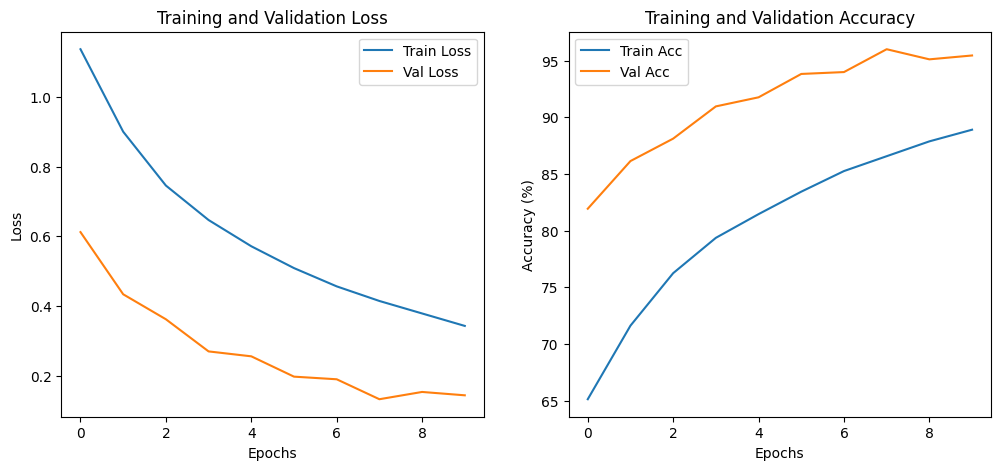

In [ ]:
# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()

# **Inference (Testing with a Single Image)**

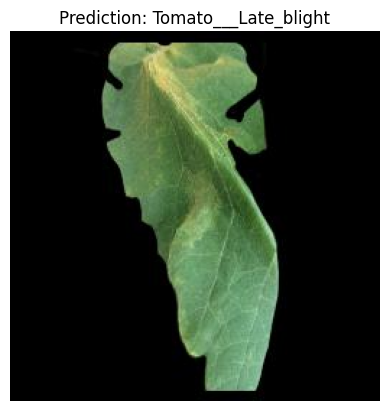

In [ ]:
def predict_image(image_path, model, transform, class_names):
    # Load and transform the image
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device) # Add batch dimension

    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        _, predicted = torch.max(outputs, 1)
        index = predicted.item()

    # Get the class name
    result = class_names[index]

    # Show the image with prediction
    plt.imshow(img)
    plt.title(f"Prediction: {result}")
    plt.axis('off')
    plt.show()

# Example usage (Testing with an image from validation set)
# Replace 'test_image_path' with an actual path to an image
test_image_path = os.path.join(VAL_PATH, classes[0], os.listdir(os.path.join(VAL_PATH, classes[0]))[0])
predict_image(test_image_path, model, val_transform, train_dataset.classes)

In [ ]:
# Save the entire model
torch.save(model.state_dict(), 'plant_disease_model.pth')
print("Model Saved Successfully!")

Model Saved Successfully!


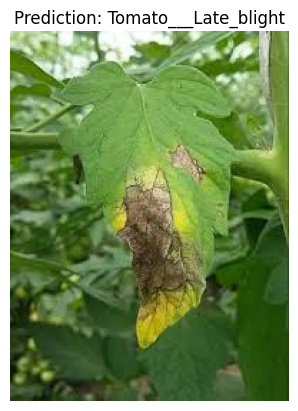

In [ ]:
external_image_path = "/tometo_lateBlight.jpg"

# Call the prediction function
predict_image(external_image_path, model, val_transform, train_dataset.classes)

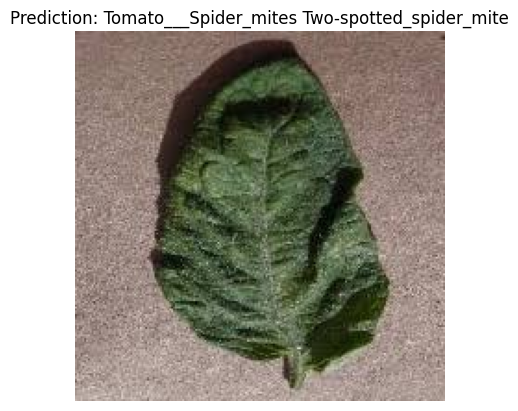

In [ ]:
external_image_path = "/tomato_spider.jpg"

# Call the prediction function
predict_image(external_image_path, model, val_transform, train_dataset.classes)

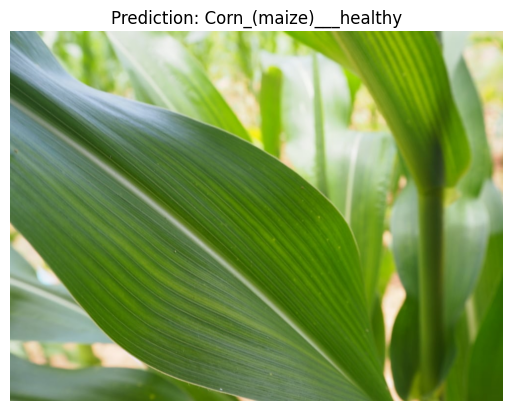

In [ ]:
external_image_path = "/corn_healthy.jpg"

# Call the prediction function
predict_image(external_image_path, model, val_transform, train_dataset.classes)

In [ ]:
import torch

# Save the model weights
torch.save(model.state_dict(), 'plant_disease_model.pth')

# Download to your computer
from google.colab import files
files.download('plant_disease_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>